# 4.6.2 有界耗散与可信积分

## 学习目标与先修知识

能推导有界性与散度（divergence）公式，手写 RK4，按共同时间点检查短窗收敛并解释长时比较的限制。

先修：4.6.1 的 Lorenz 方程、4.5 的沿轨迹（trajectory）导数（derivative）、2.4 的步长与收敛。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

为什么体积缩小的系统仍可能让两个状态（state）分离？为什么两条积分轨迹后期不同，既可能是算法问题，也可能来自敏感性？先把有界性、方向增长和计算误差拆开。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
t=np.array([0.,1.,2.])
display(Markdown(show_table(["t","伸长方向 exp(t)","收缩方向 exp(-2t)","面积 exp(-t)"],zip(t,np.exp(t),np.exp(-2*t),np.exp(-t)))))

| t | 伸长方向 exp(t) | 收缩方向 exp(-2t) | 面积 exp(-t) |
| --- | --- | --- | --- |
| 0 | 1 | 1 | 1 |
| 1 | 2.71828 | 0.135335 | 0.367879 |
| 2 | 7.38906 | 0.0183156 | 0.135335 |

## 模型假设

Lorenz 参数（parameter）严格正，固定 σ=10、β=8/3、ρ=28；初值（initial condition） [1,1,1]。RK4 用固定步长，h=.02/.01/.005 在相同 t∈[0,2] 比较；另用已经学过的显式中点法（explicit midpoint method）在更细网格作独立算法对照。所有参数是教学选择，不引入外部数据。

## 数学解释与推导

取 $W=\rho x^2+\sigma y^2+\sigma(z-2\rho)^2$。链式法则（chain rule）给出
$$\dot W=2\rho x\sigma(y-x)+2\sigma y(\rho x-y-xz)+2\sigma(z-2\rho)(xy-\beta z).$$
交叉项消去、配方后得到
$$\dot W=-2\sigma[\rho x^2+y^2+\beta(z-\rho)^2-\beta\rho^2].$$
利用 $(z-\rho)^2\ge\tfrac12(z-2\rho)^2-\rho^2$，有 $\dot W\le-cW+C$，其中 $c=\min(2\sigma,2,\beta)>0$、$C=4\sigma\beta\rho^2$。乘以积分因子 e^(ct) 并积分：
$$W(t)\le W(0)e^{-ct}+\frac Cc(1-e^{-ct}).$$
任取 K>C/c，若起步在 W≤K 内，边界向内；若在外部，上界最终小于 K。因此得到有界约束，却没有证明趋于某个平衡（equilibrium）。

**散度**是向量场（vector field）各分量对相应坐标的偏导数（partial derivative）之和。小时间 Δt 的线性变换为 I+JΔt，体积倍率 $\det(I+J\Delta t)=1+\mathrm{tr}(J)\Delta t+O(\Delta t^2)$。因此 Lorenz 小体积按 $e^{-(\sigma+1+\beta)t}$ 缩小。初步实验的 diag(1,−2) 散度也为负，却有逃逸方向；不能用体积收缩代替上面的有界证明。

经典四阶龙格–库塔法（classical fourth-order Runge–Kutta method，RK4）在段首 v 计算四个斜率（slope）：
$$k_1=f(v),\ k_2=f(v+hk_1/2),\ k_3=f(v+hk_2/2),\ k_4=f(v+hk_3),$$
$$v_{n+1}=v_n+h(k_1+2k_2+2k_3+k_4)/6.$$
它用两次中点预测修正方向。光滑且解位于有界区域时，固定终点的全局误差为 O(h⁴)，阶数证明留拓展；先用 y′=−y、y(0)=1 的解析解（analytical solution）检验这一实现。粗细网格比较必须取同一时刻，不比较不同索引。混沌（chaos）会放大极小误差，故短时比较逐点误差；长时改比较声明窗口内的几何与摘要，而不要求所有点重合。

## 核心实现

把推导逐步写成函数；不以黑箱轨迹代替方程。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([sigma*(y-x),rho*x-y-x*z,x*y-beta*z])

def rk4_step(rhs, state, h):
    a=rhs(state)
    b=rhs(state+h*a/2)
    c=rhs(state+h*b/2)
    d=rhs(state+h*c)
    return state+h*(a+2*b+2*c+d)/6

def lorenz_path(initial, sigma=10., rho=28., beta=8/3, h=.01, steps=4000):
    state=np.array(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        state=rk4_step(lambda v:lorenz_rhs(v,sigma,rho,beta),state,h)
        if not np.all(np.isfinite(state)):
            raise ValueError('数值结果非有限，请减小步长并检查参数。')
        rows.append(state.copy())
    return np.array(rows)

def lorenz_energy(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    W=rho*x*x+sigma*y*y+sigma*(z-2*rho)**2
    direct=np.dot([2*rho*x,2*sigma*y,2*sigma*(z-2*rho)],lorenz_rhs(state,sigma,rho,beta))
    completed=-2*sigma*(rho*x*x+y*y+beta*(z-rho)**2-beta*rho*rho)
    return W,direct,completed,min(2*sigma,2.,beta),4*sigma*beta*rho*rho

def midpoint_lorenz(initial,h,steps):
    state=np.array(initial,dtype=float)
    for _ in range(steps):
        state+=h*lorenz_rhs(state+h*lorenz_rhs(state)/2)
    return state

## 对照实验

线性解析误差： [np.float64(5.79695385960477e-06), np.float64(3.3324105608301124e-07), np.float64(1.9976097331841913e-08)] 相邻误差比： [17.39567725 16.68199001]
Lorenz 同时刻短窗差： [np.float64(0.012853164564069078), np.float64(0.0007490855750773803)]


C:\Users\10149\AppData\Local\Temp\ipykernel_59300\2990277912.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


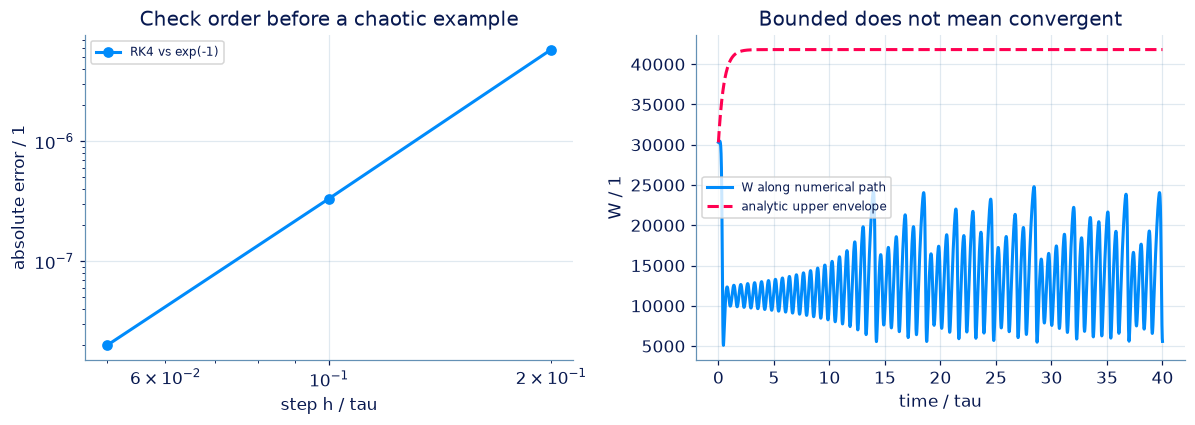

In [4]:
linear=[]
for h in [.2,.1,.05]:
    v=np.array([1.])
    for _ in range(round(1/h)):v=rk4_step(lambda x:-x,v,h)
    linear.append(abs(v[0]-math.exp(-1)))
paths=[lorenz_path([1,1,1],h=h,steps=round(2/h)) for h in [.02,.01,.005]]
errors=[np.max(np.linalg.norm(paths[0]-paths[2][::4],axis=1)),np.max(np.linalg.norm(paths[1]-paths[2][::2],axis=1))]
print('线性解析误差：',linear,'相邻误差比：',np.array(linear[:-1])/linear[1:])
print('Lorenz 同时刻短窗差：',errors)
long=lorenz_path([1,1,1],h=.01,steps=4000); times=np.arange(len(long))*.01
Ws=np.array([lorenz_energy(v)[0] for v in long]);_,_,_,c,C=lorenz_energy(long[0])
upper=Ws[0]*np.exp(-c*times)+(C/c)*(-np.expm1(-c*times))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].loglog([.2,.1,.05],linear,'o-',color=BLUE,label='RK4 vs exp(-1)')
axes[0].set(xlabel='step h / tau',ylabel='absolute error / 1',title='Check order before a chaotic example')
axes[1].plot(times,Ws,color=BLUE,label='W along numerical path');axes[1].plot(times,upper,'--',color=PINK,label='analytic upper envelope')
axes[1].set(xlabel='time / tau',ylabel='W / 1',title='Bounded does not mean convergent')
for ax in axes:ax.legend(fontsize=8)
fig.tight_layout();plt.show()

## 结果解释

线性问题的误差比随细化接近 16；Lorenz 的短窗差随步长减小。W 在解析包络内变化，但并不单调下降到零。包络较保守，这是充分界而不是最小吸收区域。若放大步长出现非有限值，应报告数值失败，不把它当成真实无界。

### 独立核对

In [5]:
assert linear[0]/linear[1]>15 and linear[1]/linear[2]>15
assert errors[0]>10*errors[1]
independent=midpoint_lorenz([1,1,1],1/32000,64000)
assert np.linalg.norm(independent-paths[-1][-1])<2e-4
for state in [[0,0,0],[1,2,3],[-3,5,20],[4,-7,60]]:
    W,a,b,c,C=lorenz_energy(state)
    assert abs(a-b)<1e-8 and a<=-c*W+C+1e-8
assert np.all(Ws<=upper+1e-4)
print('解析阶数、独立中点法、两种导数与保守界均一致。')

解析阶数、独立中点法、两种导数与保守界均一致。


[观察轨迹、距离与定向截面](http://127.0.0.1:8000/chapters/04-06-连续时间混沌与奇异吸引子/explore/)：分别改变初值与计算精度，再对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：体积收缩是否保证有界

线性系统 x′=x、y′=−2y 的散度（divergence）为 −1。可以得到什么？

- **A.** 面积缩小，但 x₀≠0 的轨迹（trajectory）可以无界逃逸。
- **B.** 每个方向都收缩。
- **C.** 所有轨迹都趋于原点。
- **D.** 负散度自动给出有界吸引区域。

[作答：体积收缩是否保证有界](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-volume-bounded)

### 第 2 题 · Python 计算题：用两条路径核对函数导数

用给定 Lorenz 方程计算有界性函数，并分别用链式法则（chain rule）与配方式核对其沿轨迹（trajectory）导数（derivative）。

**函数与代码模板**

```python
def solve(
    sigma: float,
    rho: float,
    beta: float,
    state: list[float],
) -> tuple[float, float, float, float, float]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `sigma` | `float` | 正参数（parameter） σ。 | 1 |
| `rho` | `float` | 正参数 ρ。 | 1 |
| `beta` | `float` | 正参数 β。 | 1 |
| `state` | `list[float]` | 状态（state） [x,y,z]。 | 1 |

**返回值**

按以下顺序返回元组：(W, direct, completed, c, C)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `W` | `float` | 有界性函数值。 | 1 |
| `direct` | `float` | 梯度（gradient）与向量场（vector field）内积（inner product）。 | 每单位 τ |
| `completed` | `float` | 配方后导数值。 | 每单位 τ |
| `c` | `float` | 正衰减系数。 | 每单位 τ |
| `C` | `float` | 界中常数。 | 每单位 τ |

**计算规则**

W=ρx²+σy²+σ(z−2ρ)²；direct=∇W·f；completed=−2σ[ρx²+y²+β(z−ρ)²−βρ²]；c=min(2σ,2,β)，C=4σβρ²。分别计算两种导数表达式，返回 (W,direct,completed,c,C)。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 0<σ≤20，0<ρ≤40，0<β≤5；状态各分量绝对值≤60。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| sigma | 正参数（parameter） σ。 | 10 | 1 |
| rho | 正参数 ρ。 | 2 | 1 |
| beta | 正参数 β。 | 1 | 1 |
| state | 状态（state） [x,y,z]。 | [0, 0, 0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
sigma = 10
rho = 2
beta = 1
state = [0, 0, 0]

result = solve(sigma, rho, beta, state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| W | 有界性函数值。 | 160 | 1 |
| direct | 梯度（gradient）与向量场（vector field）内积（inner product）。 | 0 | 每单位 τ |
| completed | 配方后导数值。 | 0 | 每单位 τ |
| c | 正衰减系数。 | 1 | 每单位 τ |
| C | 界中常数。 | 160 | 每单位 τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (160, 0, 0, 1, 160)
```

**样例解释**

原点 W=160，虽不为零，但两条导数均为 0；c=1，C=160。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：用两条路径核对函数导数](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-lorenz-bound)

### 第 3 题 · Python 计算题：手写四阶段的一步更新

对标量 y′=rate*y，以经典四阶龙格–库塔法计算一个时间步。

**函数与代码模板**

```python
def solve(
    initial: float,
    rate: float,
    h: float,
) -> float:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 段首状态（state）。 | 1 |
| `rate` | `float` | 连续增长率。 | 每单位 τ |
| `h` | `float` | 时间步长（time step）。 | τ |

**返回值**

直接返回 next_state（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_state` | `float` | 一步后的数值状态。 | 1 |

**计算规则**

k1=rate*y；k2=rate*(y+h*k1/2)；k3=rate*(y+h*k2/2)；k4=rate*(y+h*k3)；返回 y+h*(k1+2k2+2k3+k4)/6。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- |initial|≤10，|rate|≤3，0<h≤0.5。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 段首状态（state）。 | 1 | 1 |
| rate | 连续增长率。 | -1 | 每单位 τ |
| h | 时间步长（time step）。 | 0.5 | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 1
rate = -1
h = 0.5

result = solve(initial, rate, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_state | 一步后的数值状态。 | ≈ 0.6067708 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.6067708333333333
```

**样例解释**

四个斜率（slope）依次 −1、−0.75、−0.8125、−0.59375；一步结果 0.6067708333333334。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：手写四阶段的一步更新](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-rk4-linear-step)

### 第 4 题 · Python 计算题：只比较相同时刻的结果

粗网格状态（state）对应 t=0,h,…,Nh；细网格每个粗步分成 ratio 步。计算共同时间点的最大状态欧氏误差。

**函数与代码模板**

```python
def solve(
    coarse: list[list[float]],
    fine: list[list[float]],
    ratio: int,
) -> float:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coarse` | `list[list[float]]` | 粗网格三维状态。 | 1 |
| `fine` | `list[list[float]]` | 细网格三维状态。 | 1 |
| `ratio` | `int` | 细步数与粗步数的比例。 | 1 |

**返回值**

直接返回 max_error（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `max_error` | `float` | 所有共同时间点的最大欧氏距离。 | 1 |

**计算规则**

比较 coarse[i] 与 fine[i*ratio]；每对先算三维欧氏距离，再取最大值。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 2≤len(coarse)≤30，ratio 为 2 或 4；len(fine)=(len(coarse)−1)*ratio+1；每行长度 3。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| coarse | 粗网格三维状态。 | [[0, 0, 0], [1, 2, 3]] | 1 |
| fine | 细网格三维状态。 | [[0, 0, 0], [0.5, 1, 1.5], [1, 2, 4]] | 1 |
| ratio | 细步数与粗步数的比例。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
coarse = [[0, 0, 0], [1, 2, 3]]
fine = [[0, 0, 0], [0.5, 1, 1.5], [1, 2, 4]]
ratio = 2

result = solve(coarse, fine, ratio)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| max_error | 所有共同时间点的最大欧氏距离。 | 1 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 1.0
```

**样例解释**

t=0 的误差为 0，t=h 的两个状态仅 z 分量相差 1，因此返回 1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：只比较相同时刻的结果](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-aligned-error)

### 第 5 题 · 单项选择题：混沌轨迹怎样做收敛对照

短窗细化步长后误差下降，长窗两轨迹（trajectory）逐点分离。哪项合理？

- **A.** 先检查短窗收敛，再比较长窗截面与限定时间摘要；不能要求长窗逐点一致。
- **B.** 长窗分离一定证明积分器错误。
- **C.** 只要图像像蝴蝶就无需检查步长。
- **D.** 可以删掉不同的时刻以制造一致。

[作答：混沌轨迹怎样做收敛对照](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-short-window-check)

### 参考阅读

[MIT 非线性动力学讲义](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/pages/lecture-notes/)：第 15—16 讲的截面，第 19 讲的奇异几何，第 20—21 讲的 Lorenz 方程，第 24 讲的增长率。核心推导与实验均已写在本节。

[Rosales 有界椭球推导，第 5 节](https://math.mit.edu/classes/18.385/PSetAnswers/AnswerPSet_2020_06.pdf)。